1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [4]:
df = pd.read_excel('Placement_Dataset (3) (1).xlsx')
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


3. Data Cleaning

In [40]:
# Drop unnecessary column
df.drop(['sl_no'], axis=1, inplace=True, errors='ignore')
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,total_score,score_category
0,0,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,0,55.0,Mkt&HR,58.80,1,270000.0,68.7000,Good
1,0,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,1,86.5,Mkt&Fin,66.28,1,200000.0,75.3550,Very Good
2,0,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,0,75.0,Mkt&Fin,57.80,1,250000.0,63.7000,Good
3,0,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,0,66.0,Mkt&HR,59.43,0,0.0,54.8575,Average
4,0,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,0,96.8,Mkt&Fin,55.50,1,425000.0,72.0500,Very Good


In [41]:
df.columns

Index(['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p',
       'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status',
       'salary', 'total_score', 'score_category'],
      dtype='object')

In [25]:
# Check null values
df.isnull().sum()

gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
total_score       0
score_category    0
dtype: int64

In [35]:
# Fill missing salary with 0 (for not placed students)
df['salary'].fillna(0, inplace=True)
print(df)

     gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p   degree_t  \
0         0  67.00   Others  91.00   Others  Commerce     58.00   Sci&Tech   
1         0  79.33  Central  78.33   Others   Science     77.48   Sci&Tech   
2         0  65.00  Central  68.00  Central      Arts     64.00  Comm&Mgmt   
3         0  56.00  Central  52.00  Central   Science     52.00   Sci&Tech   
4         0  85.80  Central  73.60  Central  Commerce     73.30  Comm&Mgmt   
..      ...    ...      ...    ...      ...       ...       ...        ...   
210       0  80.60   Others  82.00   Others  Commerce     77.60  Comm&Mgmt   
211       0  58.00   Others  60.00   Others   Science     72.00   Sci&Tech   
212       0  67.00   Others  67.00   Others  Commerce     73.00  Comm&Mgmt   
213       1  74.00   Others  66.00   Others  Commerce     58.00  Comm&Mgmt   
214       0  62.00  Central  58.00   Others   Science     53.00  Comm&Mgmt   

     workex  etest_p specialisation  mba_p  status    salary  t

4. Data Manipulation

In [54]:
# Convert categorical to numeric
df['workex'] = df['workex'].map({'Yes': 1, 'No': 0})

# Placement status → numeric
df['status'] = df['status'].map({'Placed': 1, 'Not Placed': 0})

5. Data Visualization

📊 Placement Count

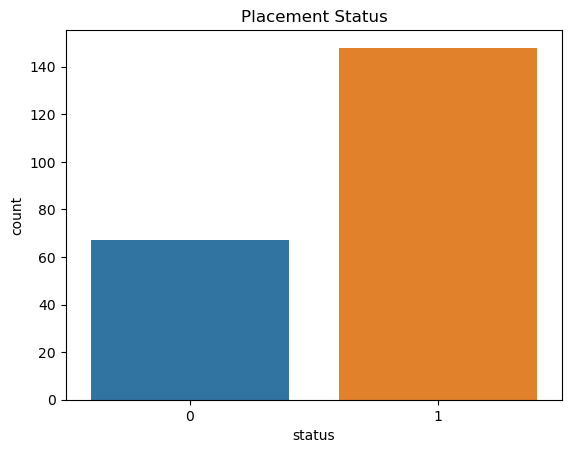

In [7]:
sns.countplot(x='status', data=df)
plt.title("Placement Status")
plt.show()

📊 Salary Distribution

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


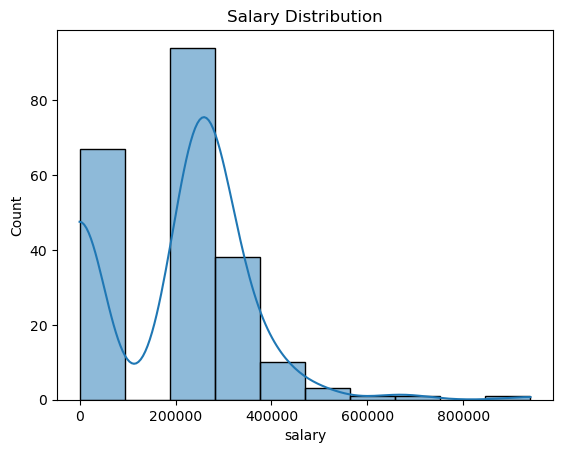

In [9]:
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

📊 SSC Marks vs Placement

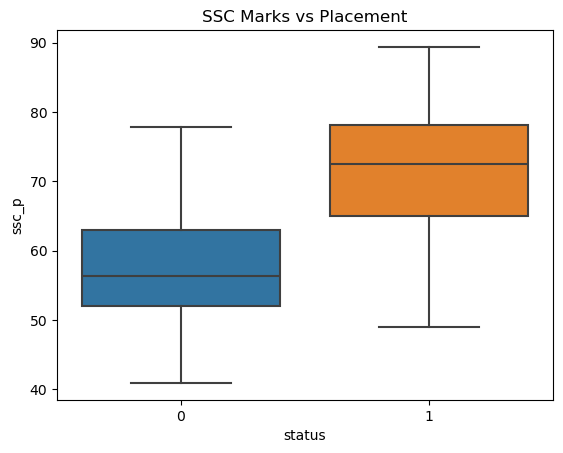

In [10]:
sns.boxplot(x='status', y='ssc_p', data=df)
plt.title("SSC Marks vs Placement")
plt.show()

📊 Placement by Gender

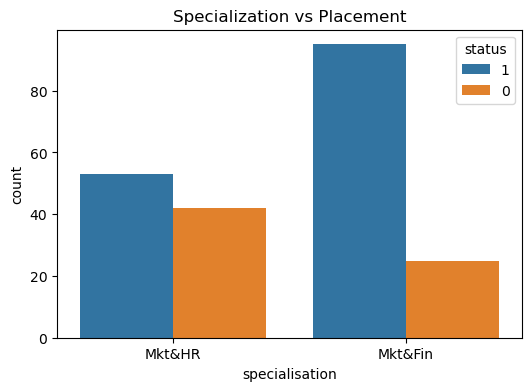

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x='specialisation', hue=df['status'].astype(str), data=df)

plt.title("Specialization vs Placement")

plt.show()

Correlation Heatmap

In [18]:
df_encoded = df.copy()

# Convert categorical columns using one-hot encoding
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

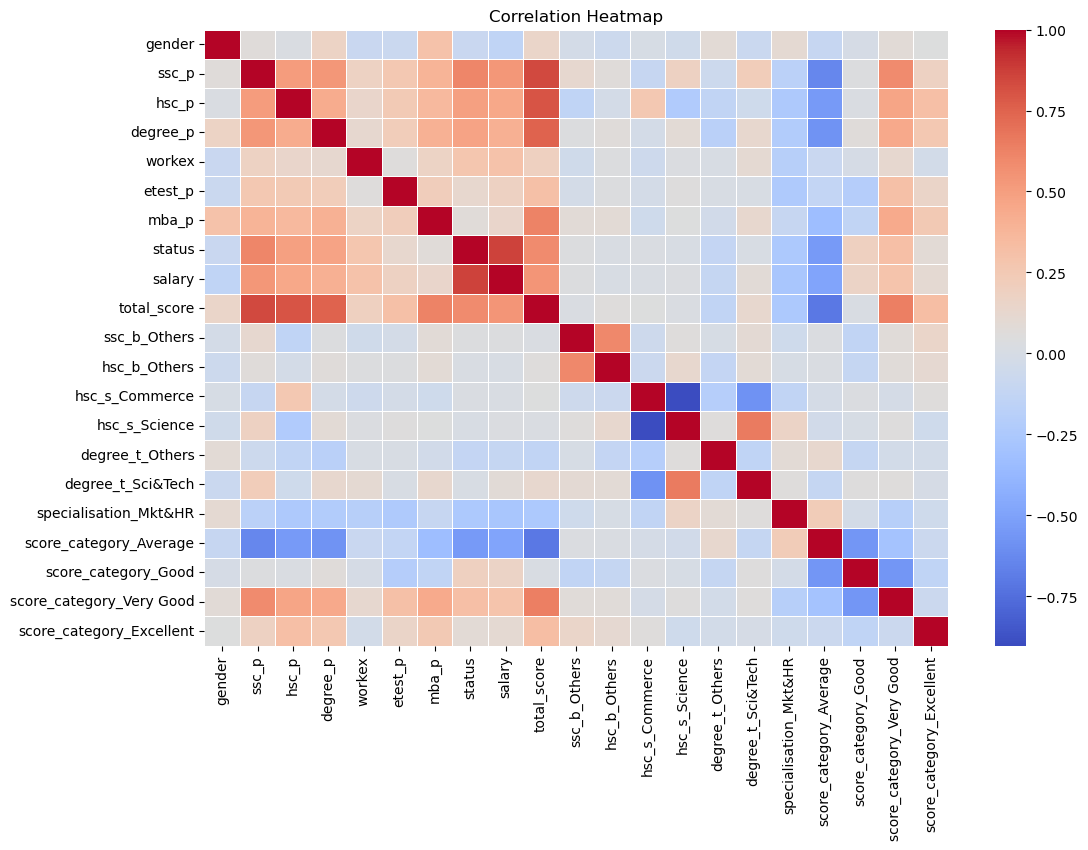

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(),
            annot=False,   # cleaner look
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

6. Feature Engineering

In [11]:
# Create total academic score
df['total_score'] = (df['ssc_p'] + df['hsc_p'] + df['degree_p'] + df['mba_p']) / 4

# Categorize scores
df['score_category'] = pd.cut(df['total_score'],
                             bins=[0, 50, 60, 70, 80, 100],
                             labels=['Poor', 'Average', 'Good', 'Very Good', 'Excellent'])

7. Insights

👉 Students with higher academic scores have better placement chances
👉 Work experience increases placement probability
👉 Marketing & Finance specialization has more placements
👉 Higher scores → higher salary

8. Final Check

In [12]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,total_score,score_category
0,0,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,0,55.0,Mkt&HR,58.80,1,270000.0,68.7000,Good
1,0,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,1,86.5,Mkt&Fin,66.28,1,200000.0,75.3550,Very Good
2,0,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,0,75.0,Mkt&Fin,57.80,1,250000.0,63.7000,Good
3,0,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,0,66.0,Mkt&HR,59.43,0,0.0,54.8575,Average
4,0,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,0,96.8,Mkt&Fin,55.50,1,425000.0,72.0500,Very Good


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   gender          215 non-null    int64   
 1   ssc_p           215 non-null    float64 
 2   ssc_b           215 non-null    object  
 3   hsc_p           215 non-null    float64 
 4   hsc_b           215 non-null    object  
 5   hsc_s           215 non-null    object  
 6   degree_p        215 non-null    float64 
 7   degree_t        215 non-null    object  
 8   workex          215 non-null    int64   
 9   etest_p         215 non-null    float64 
 10  specialisation  215 non-null    object  
 11  mba_p           215 non-null    float64 
 12  status          215 non-null    int64   
 13  salary          215 non-null    float64 
 14  total_score     215 non-null    float64 
 15  score_category  215 non-null    category
dtypes: category(1), float64(7), int64(3), object(5)
memory usage: 